Dynamic circuits are powerful tools with which you can measure qubits in the middle of a quantum circuit execution and then perform classical logic operations within the circuit, based on the outcome of those mid-circuit measurements. This process is also known as classical feedforward. While these are early days of understanding how best to take advantage of dynamic circuits, the quantum research community has already identified a number of use cases, such as the following:

- Efficient quantum state preparation, such as GHZ state, W-state (for more information about W-state, also refer to "State preparation by shallow circuits using feed forward"), and a broad class of matrix product states
- Efficient long-range entanglement between qubits on the same chip by using shallow circuits
- Efficient sampling of IQP-like circuits

## if statement

The if statement is used to conditionally perform operations based on the value of a classical bit or register.

In the example below, we apply a Hadamard gate to a qubit and measure it. If the result is 1, then we apply an X gate on the qubit, which has the effect of flipping it back to the 0 state. We then measure the qubit again. The resulting measurement outcome should be 0 with 100% probability.

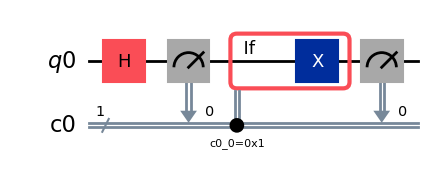

In [2]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister

qubits = QuantumRegister(1)
clbits = ClassicalRegister(1)
circuit = QuantumCircuit(qubits, clbits)
(q0,) = qubits
(c0,) = clbits

circuit.h(q0)
circuit.measure(q0, c0)
with circuit.if_test((c0, 1)):
    circuit.x(q0)
circuit.measure(q0, c0)
circuit.draw("mpl")

# example output counts: {'0': 1024}

The with statement can be given an assignment target which is itself a context manager that can be stored and subsequently used to create an else block, which is executed whenever the contents of the if block are not executed.

In the example below, we initialize registers with two qubits and two classical bits. We apply a Hadamard gate to the first qubit and measure it. If the result is 1, then we apply a Hadamard gate on the second qubit; otherwise, we apply an X gate on the second qubit. Finally, we measure the second qubit as well.




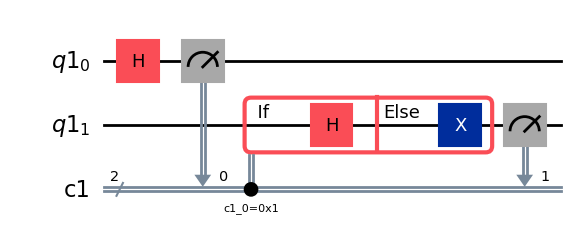

In [3]:
qubits = QuantumRegister(2)
clbits = ClassicalRegister(2)
circuit = QuantumCircuit(qubits, clbits)
(q0, q1) = qubits
(c0, c1) = clbits

circuit.h(q0)
circuit.measure(q0, c0)
with circuit.if_test((c0, 1)) as else_:
    circuit.h(q1)
with else_:
    circuit.x(q1)
circuit.measure(q1, c1)

circuit.draw("mpl")

# example output counts: {'01': 260, '11': 272, '10': 492}

In addition to conditioning on a single classical bit, it's also possible to condition on the value of a classical register composed of multiple bits.

In the example below, we apply Hadamard gates to two qubits and measure them. If the result is 01, that is, the first qubit is 1 and the second qubit is 0, then we apply an X gate to a third qubit. Finally, we measure the third qubit. Note that for clarity, we chose to specify the state of the third classical bit, which is 0, in the if condition. In the circuit drawing, the condition is indicated by the circles on the classical bits being conditioned on. A solid circle indicates conditioning on 1, while an outlined circle indicates conditioning on 0.

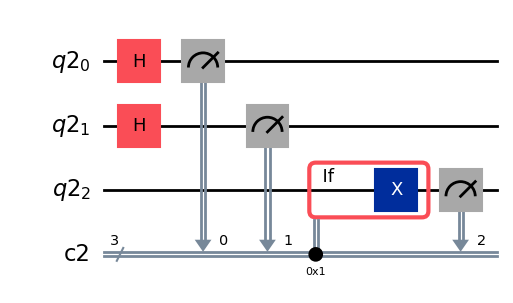

In [4]:
qubits = QuantumRegister(3)
clbits = ClassicalRegister(3)
circuit = QuantumCircuit(qubits, clbits)
(q0, q1, q2) = qubits
(c0, c1, c2) = clbits

circuit.h([q0, q1])
circuit.measure(q0, c0)
circuit.measure(q1, c1)
with circuit.if_test((clbits, 0b001)):
    circuit.x(q2)
circuit.measure(q2, c2)

circuit.draw("mpl")

# example output counts: {'101': 269, '011': 260, '000': 252, '010': 243}

## Switch statement

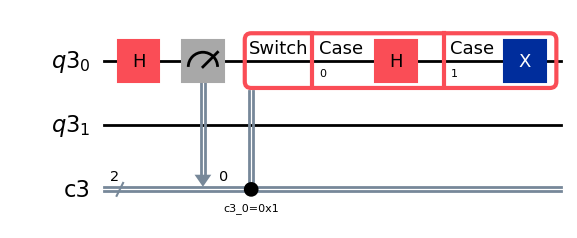

In [5]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
qubits = QuantumRegister(2)
clbits = ClassicalRegister(2)
circuit = QuantumCircuit(qubits, clbits)
(q0,q1) = qubits
(c0, c1) = clbits

circuit.h(q0)
circuit.measure(q0, c0)
with circuit.switch(c0) as case:
    with case(0):
        circuit.h(q0)
    with case(1):
        circuit.x(q0)
circuit.draw("mpl")

## For loop

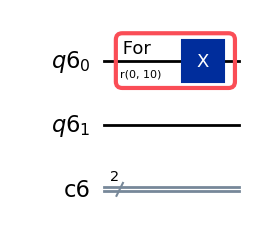

In [8]:
qubits = QuantumRegister(2)
clbits = ClassicalRegister(2)
circuit = QuantumCircuit(qubits, clbits)
(q0,q1) = qubits
(c0, c1) = clbits

with circuit.for_loop(range(10)) as _:
    circuit.x(q0)
circuit.draw('mpl')

## While loop

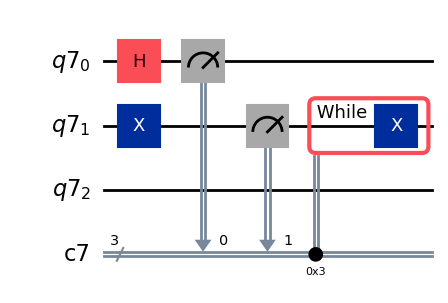

In [9]:
qubits = QuantumRegister(3)
clbits = ClassicalRegister(3)
circuit = QuantumCircuit(qubits, clbits)
(q0, q1, q2) = qubits
(c0, c1, c2) = clbits

circuit.h(q0)
circuit.x(q1)
circuit.measure(q0, c0)
circuit.measure(q1, c1)

with circuit.while_loop((clbits, 0b011)):
    circuit.x(q1)
circuit.draw('mpl')


## Classical expressions

The Qiskit classical expression module qiskit.circuit.classical contains an exploratory representation of runtime operations on classical values during circuit execution. Due to hardware limitations, only QuantumCircuit.if_test() conditions are currently supported.